In [7]:
!pip install deepface
!pip install -q mediapipe==0.10.0

In [15]:
!wget -O segmenter.tflite -q https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_segmenter_landscape/float16/latest/selfie_segmenter_landscape.tflite

In [8]:
from deepface import DeepFace
import numpy as np
from numpy.linalg import norm
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
from scipy import ndimage

Directory  /root /.deepface created
Directory  /root /.deepface/weights created


In [23]:
base_options = python.BaseOptions(model_asset_path='segmenter.tflite')
options = vision.ImageSegmenterOptions(base_options=base_options,
                                       output_category_mask=True)

def segmenter(file):
  with vision.ImageSegmenter.create_from_options(options) as segmenter:

      image = mp.Image.create_from_file(file)

      segmentation_result = segmenter.segment(image)
      mask = segmentation_result.category_mask.numpy_view()
      
      image = image.numpy_view().copy()
      image[mask == 0] = 255

      return image

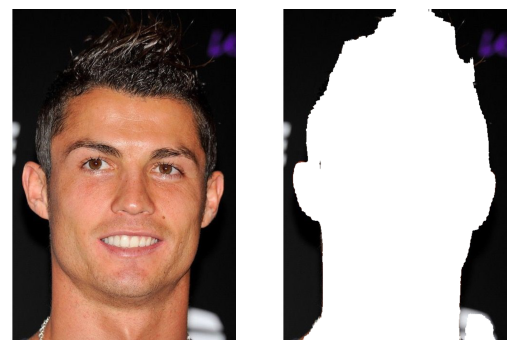

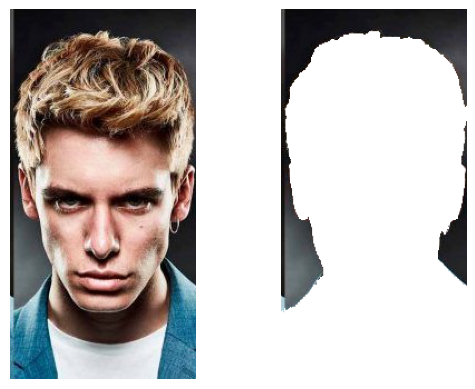

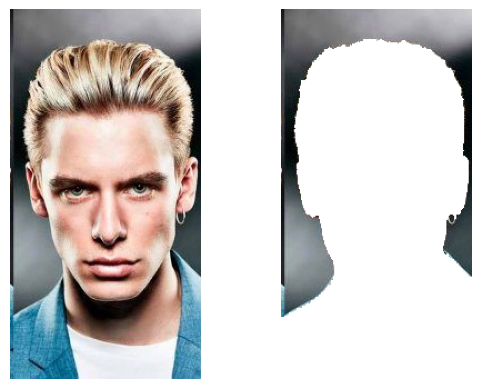

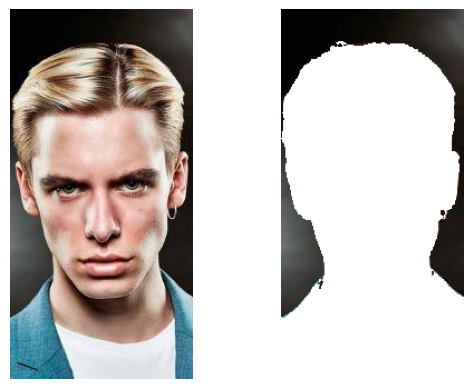

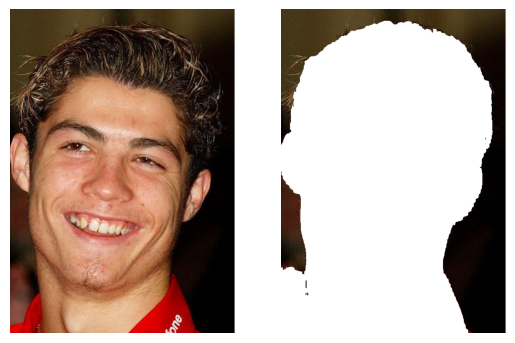

In [19]:
image_files = ['ronaldo_before.jpg','hairstyle_1.jpg','hairstyle_2.jpg','hairstyle_3.jpg','ronaldo_after.jpg']
for image_file in image_files:
  image = plt.imread(image_file)
  masked_image = segmenter(image_file)
  fig, (ax1, ax2) = plt.subplots(1, 2)
  ax1.axis('off')
  ax2.axis('off')
  ax1.imshow(image)
  ax2.imshow(masked_image)
  plt.subplots_adjust(hspace=0.3)
  plt.show()

In [55]:
def background_preservation_score(image1, image2):

    total_pixels = np.prod(image1.shape[:2])
    mismatched_pixels = np.count_nonzero(image1 - image2)
    similarity_score = 1 - (mismatched_pixels / total_pixels)
    similarity_score = round(similarity_score * 5, 2)  # Scale the score to a range of 0 to 5

    return similarity_score


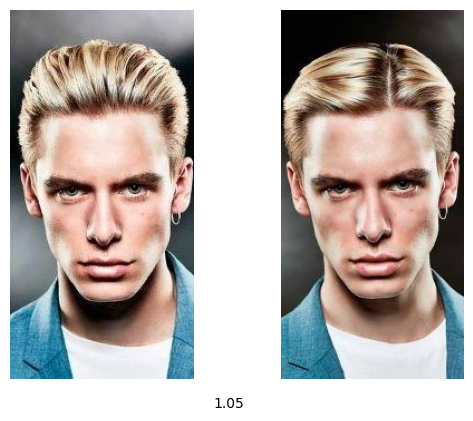

In [74]:
img1 = 'hairstyle_2.jpg'
img2 = 'hairstyle_3.jpg'
image1 = plt.imread(img1)
image2 = plt.imread(img2)
masked_image1 = segmenter(img1)
masked_image2 = segmenter(img2)
new_size = (164,333)  # Width, Height
masked_image1 = ndimage.zoom(masked_image1, (new_size[1] / masked_image1.shape[0], new_size[0] / masked_image1.shape[1], 1))
masked_image1 = masked_image1.astype(np.uint8)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.axis('off')
ax2.axis('off')
ax1.imshow(image1)
ax2.imshow(image2)
score = background_preservation_score(masked_image2,masked_image1)
plt.figtext(0.5, 0.05, str(score), ha='center')
plt.subplots_adjust(hspace=0.3)
plt.show()

In [10]:
def cos_sim(A,B):
  return np.dot(A,B)/(norm(A)*norm(B))

def indentity_preservation_score(img1,img2):
      embedding1 = np.array(DeepFace.represent(img1,model_name = "Facenet512", enforce_detection = False)[0]["embedding"])
      embedding2 = np.array(DeepFace.represent(img2,model_name = "Facenet512",enforce_detection = False)[0]["embedding"])
      return cos_sim(embedding1,embedding2) * 5

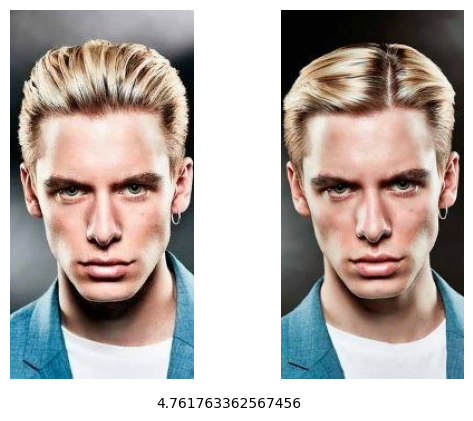

In [71]:
img1 = 'hairstyle_2.jpg'
img2 = 'hairstyle_3.jpg'
image1 = plt.imread(img1)
image2 = plt.imread(img2)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.axis('off')
ax2.axis('off')
ax1.imshow(image1)
ax2.imshow(image2)
score = indentity_preservation_score(img1,img2)
plt.figtext(0.5, 0.05, str(score), ha='center')
plt.subplots_adjust(hspace=0.3)
plt.show()